# sfig11 — Precision-Recall Curves, Additional Tasks (Supplementary Fig. S-11)

PR curves at four context lengths for tasks not shown in main paper Fig. 5.
Panels: (a) sleep efficiency, (b) sex, (c) OSA, (d) depression.

**Data**: `collected/predictions/*.parquet`, Transformer, K=all.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root ─��──────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils (TBME style, data, panels)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, FONT_TITLE, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_analysis_all_k, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
HEAD     = "transformer"
SPLIT    = "test"
CONTEXTS = ["30s", "40m", "120m", "240m"]
TASKS    = ["sleep_efficiency_binary", "sex_binary"]
            # "osa_binary_apples_postqc", "depression_extreme_binary"]

pqs = {t: load_parquets("phase0_v3", t, HEAD, SPLIT) for t in TASKS}
print("Contexts available:", {t: list(v.keys()) for t, v in pqs.items()})

Contexts available: {'sleep_efficiency_binary': ['30s', '10m', '40m', '80m', '120m', '240m'], 'sex_binary': ['30s', '10m', '40m', '80m', '120m', '240m']}


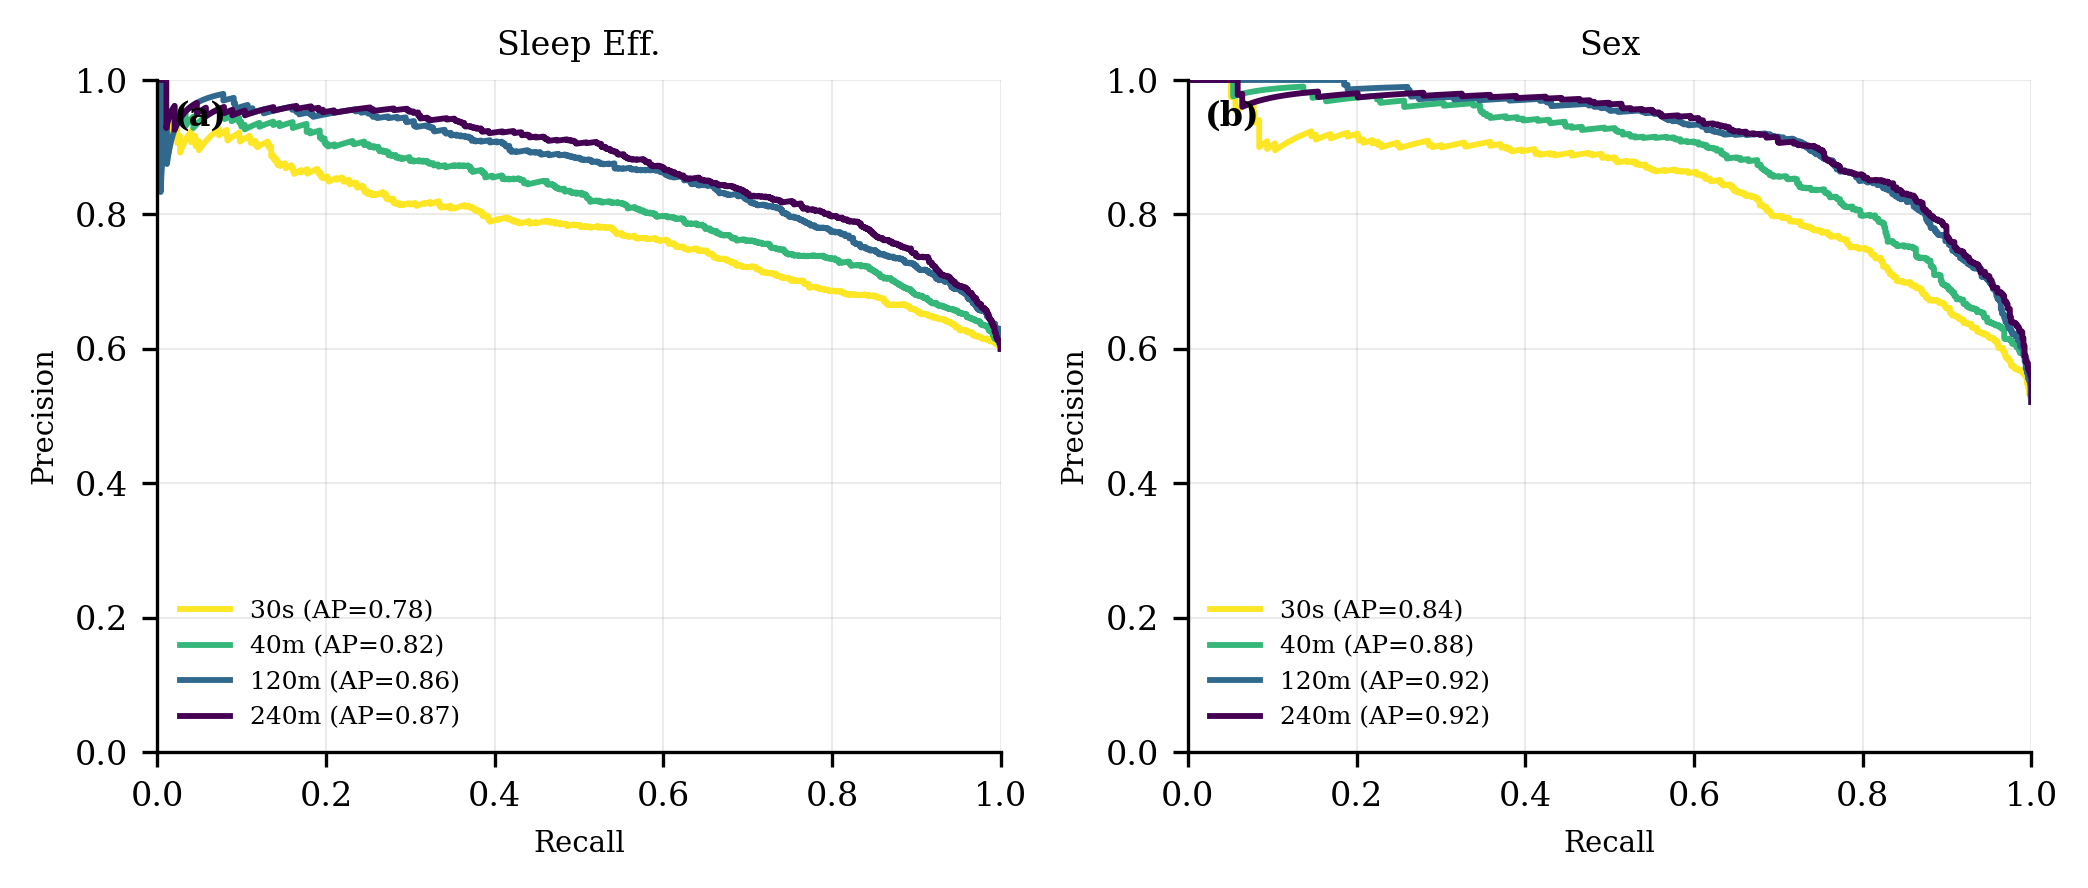

In [8]:
fig, _axes = plt.subplots(1, 2, figsize=(FULL_W, 3))
for _i, (_ax, _task) in enumerate(zip(_axes.flatten(), TASKS)):
    panels.pr_curves_panel(_ax, pqs[_task], contexts=CONTEXTS)
    _ax.set_title(TASK_LABEL[_task], fontsize=FONT_TITLE)
    add_panel_label(_ax, f'({chr(97+_i)})')
fig.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

In [9]:
save_figure(fig, FINAL_OUT, "sfig11_pr_curves")
import shutil
shutil.copy(FINAL_OUT / "sfig11_pr_curves.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig11_pr_curves.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig11_pr_curves.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig9_pr_curves.pdf
Saved + copied → TBME_submission/sfig9_pr_curves.pdf
